 #  Arctic Plots: Sea Ice and Temp in NH for Jan and Jul

## Origin of Files

In [30]:
#Short history of commands and origin of files:
# The commands are for the PI dataset, the other datasets have been created exactly analogous 
# just the names of the files have been exchanged, they can be found in the folders
# /data/modeldata/ICON/icon-paleo/LIG.kepler/remapped_r2b4  &  ./data/modeldata/ICON/icon-paleo/LIG.kepler.ghg/remapped_r2b4
#
#Merging:
#        cdo mergetime ../PI.kepler.mk_atm_2d_ml_*.nc PI.kepler_atm2d_merged.nc
#
#Regridding:
#        getting gridfiles/icon_grid_0012_R02B04_G.nc
#                ==> downloaded original from ICON paleo website, is the gridfile for R02B04 grid
#        creating gridfiles/target_grid_1_5.txt
#                ==> got from Kiras 0.75 grid, changed numbers pretty self explanatory!
#
#        Creating weightfile in gridfiles:
#        cdo gendis,gridfiles/target_grid_1_5.txt -setgrid,gridfiles/icon_grid_0012_R02B04_G.nc  PI.kepler_atm2d_merged.nc gridfiles/weightfile_R02B04_to_1_5_deg
#
#        Actual Remapping:
#        cdo -remap,gridfiles/target_grid_1_5.txt,gridfiles/weightfile_R02B04_to_1_5_deg PI.kepler_atm2d_merged.nc PI.kepler_atm2d_merged_remapped.nc
#
#Selecting the relevant years:
#        cdo selyear,1770/1800 PI.kepler_atm2d_merged_remapped.nc PI.kepler_atm2d_merged_remapped_1770_1800.nc


#        Isolating Temperature and Sea Ice:
#        for whole data
#        cdo selname,t_2m,fr_seaice PI.kepler_atm2d_merged_remapped.nc PI.kepler_t2m_sif_merged_remapped.nc


## Basic Import Statements

In [31]:
# %%
import xarray as xr
import numpy as np
#from scipy.stats import pearsonr
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
#from tqdm import tqdm

## Loading rcParams

In [32]:
import importlib
import plot_settings
importlib.reload(plot_settings)

plot_settings.load_rcParams()

## Loading Data

In [33]:
PI  = xr.open_dataset('../PI.kepler/remapped_r2b4/PI.kepler_t2m_sif_merged_remapped.nc')
LIG = xr.open_dataset('../LIG.kepler/remapped_r2b4/LIG.kepler_t2m_sif_merged_remapped.nc')
LIG_ghg = xr.open_dataset('../LIG.kepler.ghg/remapped_r2b4/LIG.kepler.ghg_t2m_sif_merged_remapped.nc')

## Usefull functions for deriving the GMST

In [34]:
def extract_NH(PI: xr.DataArray) -> xr.DataArray:
    return PI.sel(lat=PI.lat > 0)

def get_lat_weights(PI: xr.DataArray) -> xr.DataArray:
    """Create cosine-based latitude weights."""
    return np.cos(np.deg2rad(PI.lat))

def get_weighted_mean(PI: xr.DataArray) -> xr.DataArray:
    PI = PI.squeeze('height_2')
    weights = get_lat_weights(PI)
    PI_lat_weighted = PI.weighted(weights)
    
    return PI_lat_weighted.mean(dim=['lat', 'lon'])

def get_annual_mean(PI: xr.DataArray) -> xr.DataArray:
    """Resample to annual frequency and take the mean."""
    return PI.resample(time='YS').mean()

def get_Jul_mean(PI: xr.DataArray) -> xr.DataArray:
    """Return the mean over all July months."""
    return PI.sel(time=PI.time.dt.month == 7).resample(time='YS').mean()

def get_Jan_mean(PI: xr.DataArray) -> xr.DataArray:
    """Return the mean over all July months."""
    return PI.sel(time=PI.time.dt.month == 1).resample(time='YS').mean()

def get_annual_mean_from_raw_dataset(PI: xr.DataArray) -> xr.DataArray:
    PI_mean = get_weighted_mean(PI.t_2m)
    PI_annual = get_annual_mean(PI_mean)
    PI_annual = PI_annual[:-1] # cutoff last "year" as it is just the 01.01. of the new year, which has not been simulated
    return PI_annual

def get_Jul_mean_from_raw_dataset(PI: xr.DataArray) -> xr.DataArray:
    PI_mean = get_weighted_mean(PI.t_2m)
    PI_Jul  = get_Jul_mean(PI_mean)
    PI_Jul = PI_Jul[:-1] # cutoff last "year" as it is just the 01.01. of the new year, which has not been simulated
    return PI_Jul

def get_Jan_mean_from_raw_dataset(PI: xr.DataArray) -> xr.DataArray:
    PI_mean = get_weighted_mean(PI.t_2m)
    PI_Jan  = get_Jan_mean(PI_mean)
    PI_Jan = PI_Jan[:-1] # cutoff last "year" as it is just the 01.01. of the new year, which has not been simulated
    return PI_Jan

## Deriving the GMST

In [35]:
# extracting NH
PI_NH      = extract_NH(PI)
LIG_NH     = extract_NH(LIG)
LIG_ghg_NH = extract_NH(LIG_ghg)

# get Jul means
PI_Jul_NH = get_Jul_mean_from_raw_dataset(PI_NH)
LIG_Jul_NH = get_Jul_mean_from_raw_dataset(LIG_NH)
LIG_ghg_Jul_NH = get_Jul_mean_from_raw_dataset(LIG_ghg_NH)

# get Jan means
PI_Jan_NH = get_Jan_mean_from_raw_dataset(PI_NH)
LIG_Jan_NH = get_Jan_mean_from_raw_dataset(LIG_NH)
LIG_ghg_Jan_NH = get_Jan_mean_from_raw_dataset(LIG_ghg_NH)

## Plotting Jul Mean of NH

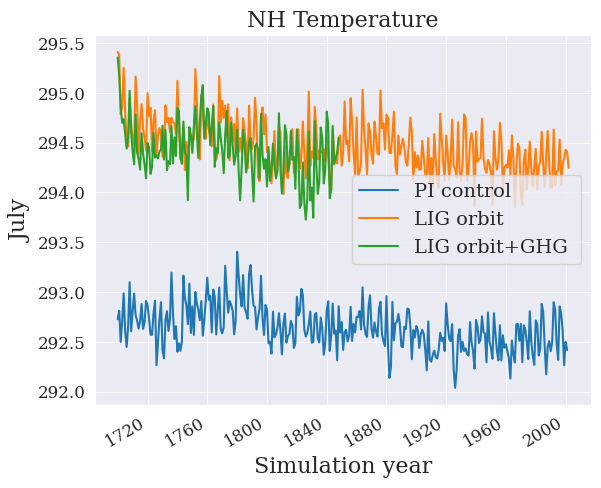

In [36]:
PI_Jul_NH.plot(label='PI control ')
LIG_Jul_NH.plot(label='LIG orbit ')
LIG_ghg_Jul_NH.plot(label='LIG orbit+GHG ')
ax = plt.gca()
ax.set_title('NH Temperature')
ax.set_ylabel('July')
ax.set_xlabel('Simulation year')
ax.legend()
plt.savefig('figs/GMST.png')

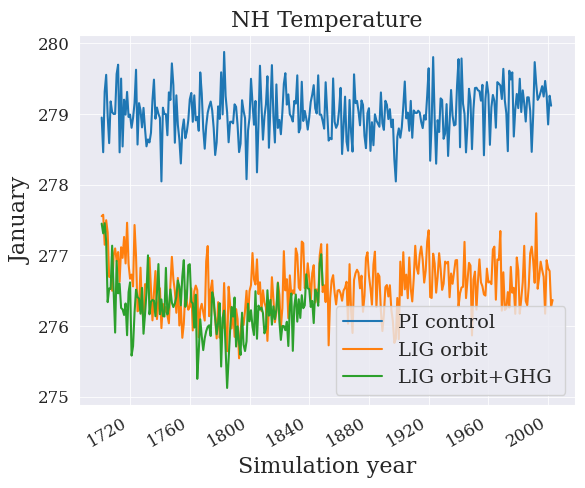

In [37]:
PI_Jan_NH.plot(label='PI control ')
LIG_Jan_NH.plot(label='LIG orbit ')
LIG_ghg_Jan_NH.plot(label='LIG orbit+GHG ')
ax = plt.gca()
ax.set_title('NH Temperature')
ax.set_ylabel('January')
ax.set_xlabel('Simulation year')
ax.legend()
plt.savefig('figs/GMST.png')